***type something cool later***

*notes:*

target is 5,174 (active) : 1,869 (churned) / 7,043 (total)... (~27%)... class_weight='balanced'

stratify=target... maintain the ~27% imbalance environment for train/test sets

In [1]:
import pandas as pd
import numpy as np
import math as mt
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

data_contract = pd.read_csv('contract.csv')
data_internet = pd.read_csv('internet.csv')
data_personal = pd.read_csv('personal.csv')
data_phone = pd.read_csv('phone.csv')

display(data_contract.head())
display(data_internet.head())
display(data_personal.head())
display(data_phone.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [2]:
    #!! converting date columns to datetime format
warnings.filterwarnings('ignore')
data_contract['BeginDate'] = pd.to_datetime(data_contract['BeginDate'])
data_contract['EndDate'] = pd.to_datetime(data_contract['EndDate'], errors='coerce')
warnings.filterwarnings('default')

    #!! filling NaT (EndDate = 'No') with 'current day' (data set extraction date 2020-02-01)
data_contract['EndDate'] = data_contract['EndDate'].fillna(pd.Timestamp('2020-02-01'))

    #!! calculating tenure in months
data_contract['tenure_month'] = (data_contract['EndDate'] - data_contract['BeginDate']).dt.days // 30

    #!! dropping BeginDate (no relationship with customer loyalty)
data_contract = data_contract.drop('BeginDate', axis=1)

    #!! converting TotalCharges to numeric, coercing errors to NaN, then filling NaN with 0
data_contract['TotalCharges'] = pd.to_numeric(data_contract['TotalCharges'], errors='coerce')
data_contract['TotalCharges'] = data_contract['TotalCharges'].fillna(0)

    #!! converting EndDate to boolean (int64): 0 = active (2020-02-01), 1 = churned (other dates)
data_contract['EndDate'] = data_contract['EndDate'].apply(lambda x: 0 if x == pd.Timestamp('2020-02-01') else 1)

    #!! data_contract columns renamed
data_contract.rename(columns={'EndDate': 'churned', 'Type': 'contract_type', 'PaperlessBilling': 'paperless_billing',
                              'PaymentMethod': 'payment_method', 'MonthlyCharges': 'monthly_charges', 'TotalCharges': 'total_charges'}, inplace=True)

**- *['tenure_month']* column added using 'BeginDate' & 'EndDate'... *['BeginDate']* & *['TotalCharges']* dropped for reasons specified above... *['EndDate']* converted into binary int64 column where (0 = active, 1 = churned)... *['EndDate']* renamed to *['churned']*, and all columns converted to snake case (except customerID)**

In [3]:
    #!! data_internet columns renamed
data_internet.rename(columns={'InternetService': 'internet_service', 'OnlineSecurity': 'online_security',
                              'OnlineBackup': 'online_backup', 'DeviceProtection': 'device_protection',
                              'TechSupport': 'tech_support', 'StreamingTV': 'streaming_tv',
                              'StreamingMovies': 'streaming_movies'}, inplace=True)

**- all columns within the internet.csv data set have been converted to snake case**

In [4]:
    #!! dropping gender column (no relationship with customer loyalty)
data_personal = data_personal.drop('gender', axis=1)

    #!! data_personal columns renamed
data_personal.rename(columns={'SeniorCitizen': 'senior_citizen', 'Partner': 'partner',
                              'Dependents': 'dependents'}, inplace=True)

**- *['gender']* has been dropped from the peronal.csv data set, since it has no predictive power in the context of customer retention... all columns converted to snake case**

In [5]:
    #!! data_phone columns renamed
data_phone.rename(columns={'MultipleLines': 'multiple_lines'}, inplace=True)

**- snake case conversion for phone.csv column**

In [6]:
#data_contract.info()
#data_internet.info()
#data_personal.info()
#data_phone.info()

display(data_contract.head())
display(data_internet.head())
display(data_personal.head())
display(data_phone.head())

    #!! checking unique values
#for col in data_contract.select_dtypes(include=['object', 'int64']).columns: display(data_contract[col].value_counts())

    #!! checking unique values
#for col in data_internet.select_dtypes(include=['object']).columns: display(data_internet[col].value_counts())

    #!! checking unique values
#for col in data_personal.select_dtypes(include=['object', 'int64']).columns: display(data_personal[col].value_counts())

    #!! checking unique values
#for col in data_phone.select_dtypes(include=['object']).columns: display(data_phone[col].value_counts())

,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month
0,7590-VHVEG,0,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,5575-GNVDE,0,One year,No,Mailed check,56.95,1889.50,34
2,3668-QPYBK,1,Month-to-month,Yes,Mailed check,53.85,108.15,2
3,7795-CFOCW,0,One year,No,Bank transfer (automatic),42.30,1840.75,45
4,9237-HQITU,1,Month-to-month,Yes,Electronic check,70.70,151.65,2


,customerID,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,senior_citizen,partner,dependents
0,7590-VHVEG,0,Yes,No
1,5575-GNVDE,0,No,No
2,3668-QPYBK,0,No,No
3,7795-CFOCW,0,No,No
4,9237-HQITU,0,No,No


,customerID,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


**- misc print and display loops to monitor the integrity of our features**

In [7]:
    #!! merging all dataframes on customerID
data = data_contract.merge(
    data_internet, on='customerID', how='left').merge(
        data_personal, on='customerID', how='left').merge(
            data_phone, on='customerID', how='left')

#data.info()
#display(data.head())
#display(data['multiple_lines'].value_counts())

    #!! filling 'No Service' for NaN values (customers without internet or phone service)
data.fillna('No Service', inplace=True)

    #!! creating binary columns for internet and phone service (0 = No Service, 1 = has service)
data['has_internet'] = data['internet_service'].apply(lambda x: 0 if x == 'No Service' else 1)
data['has_phone'] = data['multiple_lines'].apply(lambda x: 0 if x == 'No Service' else 1)

#data.info()
display(data.head())
#display(data['multiple_lines'].value_counts())

,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,senior_citizen,partner,dependents,multiple_lines,has_internet,has_phone
0,7590-VHVEG,0,Month-to-month,Yes,Electronic check,29.85,29.85,1,DSL,No,...,No,No,No,No,0,Yes,No,No Service,1,0
1,5575-GNVDE,0,One year,No,Mailed check,56.95,1889.50,34,DSL,Yes,...,Yes,No,No,No,0,No,No,No,1,1
2,3668-QPYBK,1,Month-to-month,Yes,Mailed check,53.85,108.15,2,DSL,Yes,...,No,No,No,No,0,No,No,No,1,1
3,7795-CFOCW,0,One year,No,Bank transfer (automatic),42.30,1840.75,45,DSL,Yes,...,Yes,Yes,No,No,0,No,No,No Service,1,0
4,9237-HQITU,1,Month-to-month,Yes,Electronic check,70.70,151.65,2,Fiber optic,No,...,No,No,No,No,0,No,No,No,1,1


**- new df *'data'* containing all 4 files merged left onto contract.csv *['customerID']*... missing values have been replaced with *'No Service'* to specify a 3rd option when customers haven't subscribed to either phone or internet... 2 binary columns introduced for clarity regarding which service the customer is paying for *['has_internet', 'has_phone']***

In [8]:
    #!! OHE categorical features, dropping customerID
data_ohe = pd.get_dummies(data.drop('customerID', axis=1), drop_first=True)

    #!! splitting data into train and test sets (80/20), stratifying on target variable 'churned' (imbalanced classes)
data_train, data_test = train_test_split(data_ohe, test_size=0.2, random_state=777, stratify=data_ohe['churned'])

    #!! training set features and target
features_train = data_train.drop('churned', axis=1)
target_train = data_train['churned']

    #!! test set features and target
features_test = data_test.drop('churned', axis=1)
target_test = data_test['churned']

    #!! initiating StandardScaler
numeric = ['monthly_charges', 'total_charges', 'tenure_month']
scaler = StandardScaler()
scaler.fit(features_train[numeric])

    #!! scaling non-binary numeric columns
features_train[numeric] = scaler.transform(features_train[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

#display(data_ohe.head())
#print(data_ohe.info())

display(data_train.head())
#print(data_train.info())
#print(data_train['churned'].value_counts())

display(data_test.head())
#print(data_test.info())
#print(data_test['churned'].value_counts())

display(features_train.head())
display(features_test.head())

,churned,monthly_charges,total_charges,tenure_month,senior_citizen,has_internet,has_phone,contract_type_One year,contract_type_Two year,paperless_billing_Yes,...,tech_support_No Service,tech_support_Yes,streaming_tv_No Service,streaming_tv_Yes,streaming_movies_No Service,streaming_movies_Yes,partner_Yes,dependents_Yes,multiple_lines_No Service,multiple_lines_Yes
5886,0,19.75,948.9,47,0,0,1,False,True,False,...,True,False,True,False,True,False,True,True,False,False
3460,0,100.05,4834.0,48,0,1,1,False,False,True,...,False,True,False,True,False,True,True,False,False,False
4875,1,117.45,5438.9,48,1,1,1,False,False,False,...,False,True,False,True,False,True,True,False,False,True
5193,0,26.45,1914.5,73,0,0,1,False,True,False,...,True,False,True,False,True,False,True,False,False,True
1717,0,19.70,1421.9,73,0,0,1,False,True,False,...,True,False,True,False,True,False,True,False,False,False


,churned,monthly_charges,total_charges,tenure_month,senior_citizen,has_internet,has_phone,contract_type_One year,contract_type_Two year,paperless_billing_Yes,...,tech_support_No Service,tech_support_Yes,streaming_tv_No Service,streaming_tv_Yes,streaming_movies_No Service,streaming_movies_Yes,partner_Yes,dependents_Yes,multiple_lines_No Service,multiple_lines_Yes
5970,0,89.15,413.25,5,0,1,1,False,False,True,...,False,False,False,False,False,True,True,False,False,True
3350,1,44.15,44.15,1,0,1,1,False,False,True,...,False,False,False,False,False,False,False,False,False,False
5115,0,65.65,3047.15,46,0,1,1,False,True,False,...,False,True,False,False,False,False,True,False,False,False
5437,1,61.60,1174.35,20,1,1,1,False,False,True,...,False,False,False,False,False,True,False,False,False,True
4725,1,62.05,62.05,1,0,1,1,False,False,False,...,False,True,False,False,False,False,False,False,False,True


,monthly_charges,total_charges,tenure_month,senior_citizen,has_internet,has_phone,contract_type_One year,contract_type_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),...,tech_support_No Service,tech_support_Yes,streaming_tv_No Service,streaming_tv_Yes,streaming_movies_No Service,streaming_movies_Yes,partner_Yes,dependents_Yes,multiple_lines_No Service,multiple_lines_Yes
5886,-1.484345,-0.584025,0.583743,0,0,1,False,True,False,False,...,True,False,True,False,True,False,True,True,False,False
3460,1.178155,1.137181,0.624126,0,1,1,False,False,True,True,...,False,True,False,True,False,True,True,False,False,False
4875,1.755085,1.405168,0.624126,1,1,1,False,False,False,False,...,False,True,False,True,False,True,True,False,False,True
5193,-1.262194,-0.156238,1.633705,0,0,1,False,True,False,True,...,True,False,True,False,True,False,True,False,False,True
1717,-1.486003,-0.374473,1.633705,0,0,1,False,True,False,True,...,True,False,True,False,True,False,True,False,False,False


,monthly_charges,total_charges,tenure_month,senior_citizen,has_internet,has_phone,contract_type_One year,contract_type_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),...,tech_support_No Service,tech_support_Yes,streaming_tv_No Service,streaming_tv_Yes,streaming_movies_No Service,streaming_movies_Yes,partner_Yes,dependents_Yes,multiple_lines_No Service,multiple_lines_Yes
5970,0.816745,-0.821333,-1.112351,0,1,1,False,False,True,False,...,False,False,False,False,False,True,True,False,False,True
3350,-0.675316,-0.984854,-1.273883,0,1,1,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
5115,0.037557,0.345557,0.543359,0,1,1,False,True,False,False,...,False,True,False,False,False,False,True,False,False,False
5437,-0.096728,-0.484144,-0.506603,1,1,1,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
4725,-0.081808,-0.976924,-1.273883,0,1,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True


**- categorical features encoded using OHE... data split 80/20 into train/test sets, stratifying on our target variable to maintain the 36% churn class imbalance... train and test sets split into features/target... standard scaler fit on training set, non-binary numeric columns only *('monthly_charges', 'tenure_month')*... training and test numeric features scaled... data ready for model training**

In [9]:
#!! function to evaluate classification model performance (Accuracy, F1, APS, ROC-AUC) with plots (F1, ROC, PRC)
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

**- function from previous project used to evaluate binary classification models under various metrics... including the primary metrics used for this project evaluation (Accuracy, ROC-AUC >= .88)**

## Baseline Model: DummyClassifier

          train  test
Accuracy   0.73  0.73
F1         0.00  0.00
APS        0.27  0.27
ROC AUC    0.50  0.50


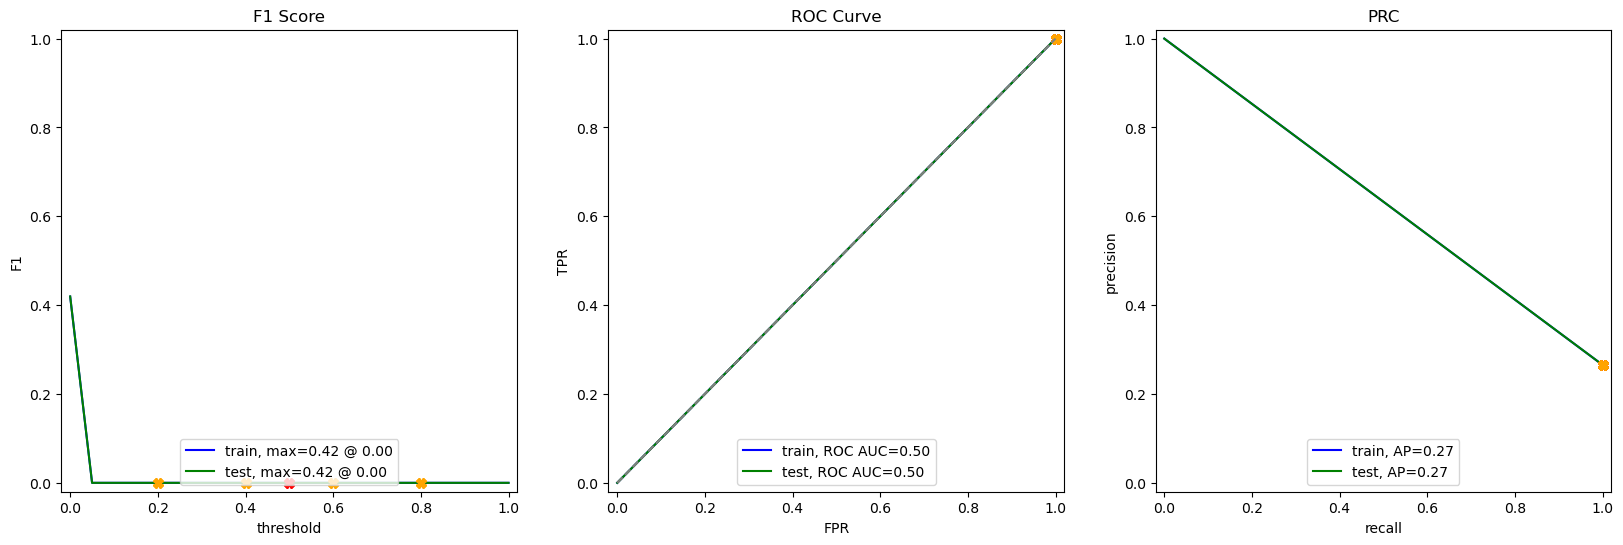

In [10]:
    #!! establishing baseline model (Dummy Classifier)
dummy_model = DummyClassifier(strategy='most_frequent', random_state=777)
dummy_model.fit(features_train, target_train)

evaluate_model(dummy_model, features_train, target_train, features_test, target_test)

**- As expected, predicting the majority class (0 = active) for every observation will result in being correct 73% of the time, this also means our model has no capability to distinguish between classes, hence the .50 ROC-AUC score**

## LogisticRegression

          train  test
Accuracy   0.75  0.75
F1         0.63  0.64
APS        0.66  0.66
ROC AUC    0.85  0.85


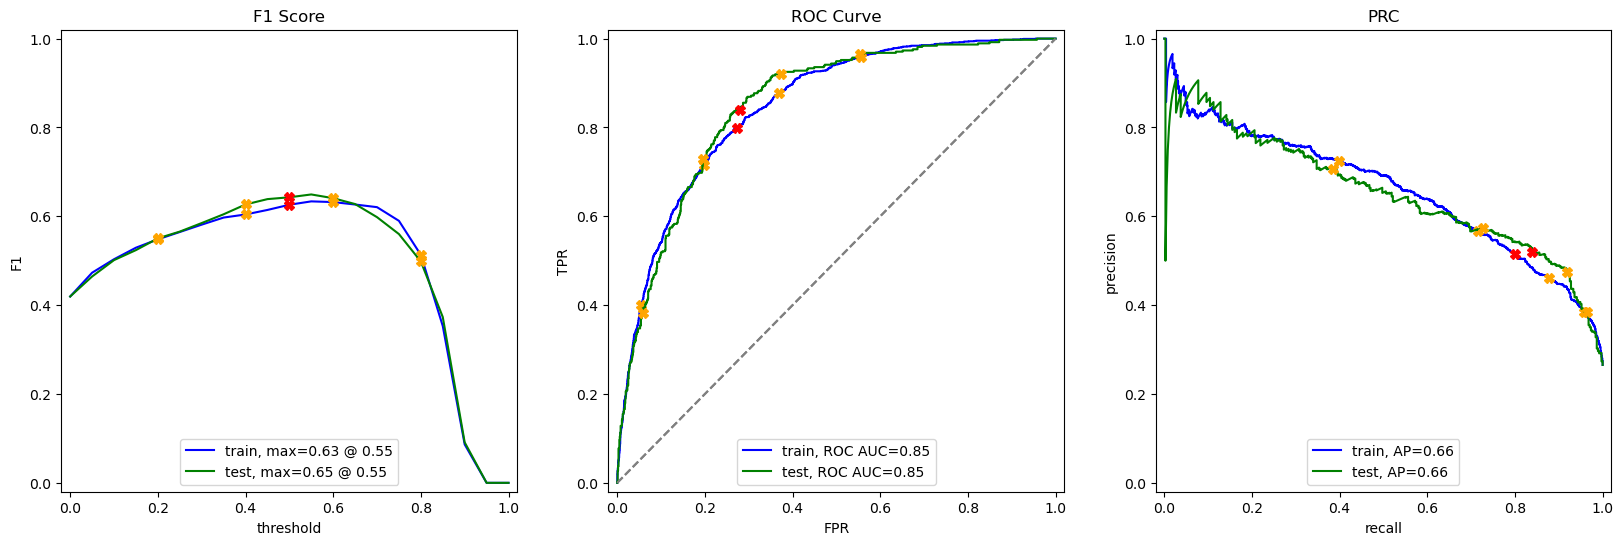

In [11]:
    #!! logistic regression model with balanced class weights
log_model = LogisticRegression(class_weight='balanced', random_state=777)
log_model.fit(features_train, target_train)

evaluate_model(log_model, features_train, target_train, features_test, target_test)

**- Our accuracy has improved by roughly 3% using LogisticRegression over DummyClassifier, with a ROC-AUC of .85 on both the training and test sets. LogisticRegression will serve as our model to overcome moving forward.**

## DecisionTreeClassifier

In [12]:
#!! looping through max_depth to find optimal value
best_model = None
best_score = 0
for depth in range(1, 21):
    tree_model = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=777)
    tree_model.fit(features_train, target_train)
    pred_prob = tree_model.predict_proba(features_test)[:, 1]
    roc_auc = metrics.roc_auc_score(target_test, pred_prob)
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = tree_model

print('ROC-AUC of best model:', best_score)
print('Best Model:', best_model)

ROC-AUC of best model: 0.8328902839133019
Best Model: DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=777)


          train  test
Accuracy   0.75  0.72
F1         0.64  0.61
APS        0.65  0.61
ROC AUC    0.86  0.83


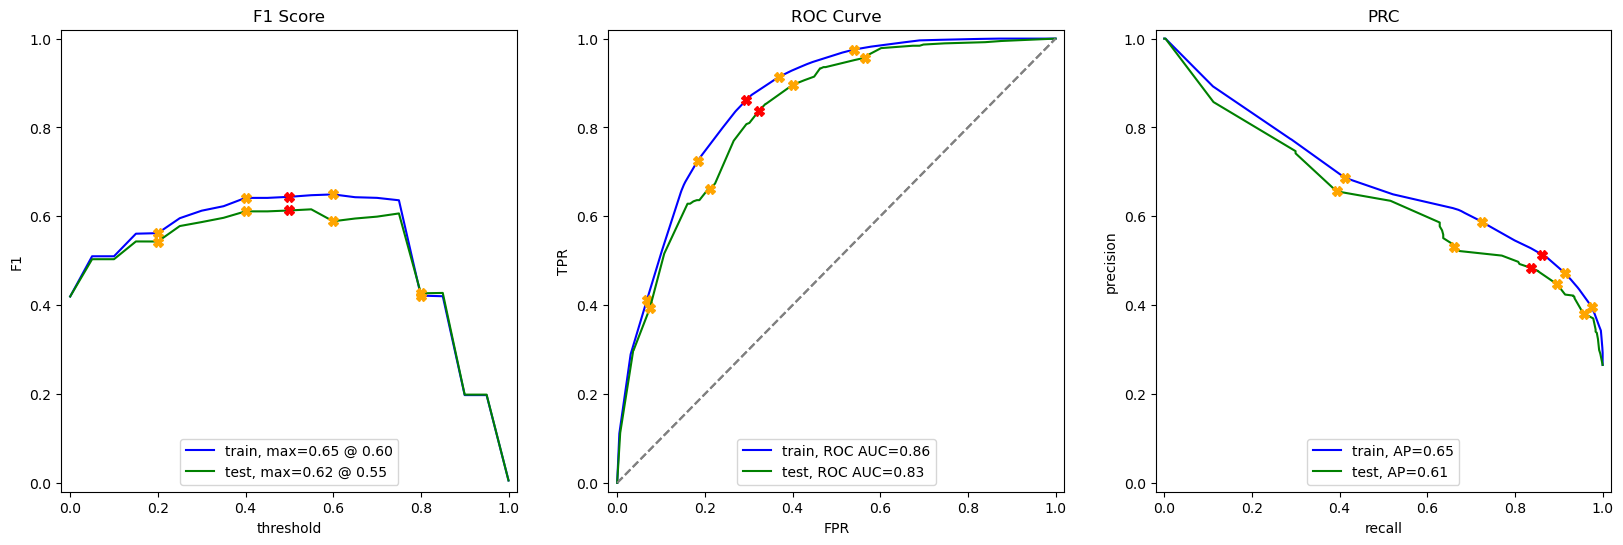

In [13]:
    #!! decision tree model with optimal max_depth
tree_model = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=777)
tree_model.fit(features_train, target_train)

evaluate_model(tree_model, features_train, target_train, features_test, target_test)

**- DecisionTreeClassifier scored worse than LogisticRegression in every metric against the test set, so we will be moving onto RandomForest.**

## RandomForestClassifier

In [14]:
#!! looping through n_estimators and max_depth to find optimal values
best_model = None
best_score = 0
for est in range(3, 33, 3):
    for depth in range(1, 21):
        rf_model = RandomForestClassifier(n_estimators=est, max_depth=depth, class_weight='balanced', random_state=777)
        rf_model.fit(features_train, target_train)
        pred_prob = rf_model.predict_proba(features_test)[:, 1]
        roc_auc = metrics.roc_auc_score(target_test, pred_prob)
        if roc_auc > best_score:
            best_score = roc_auc
            best_model = rf_model

print('ROC-AUC of best model:', best_score)
print('Best Model:', best_model)

ROC-AUC of best model: 0.8433723423493243
Best Model: RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=30,
                       random_state=777)


          train  test
Accuracy   0.80  0.77
F1         0.69  0.64
APS        0.74  0.63
ROC AUC    0.89  0.84


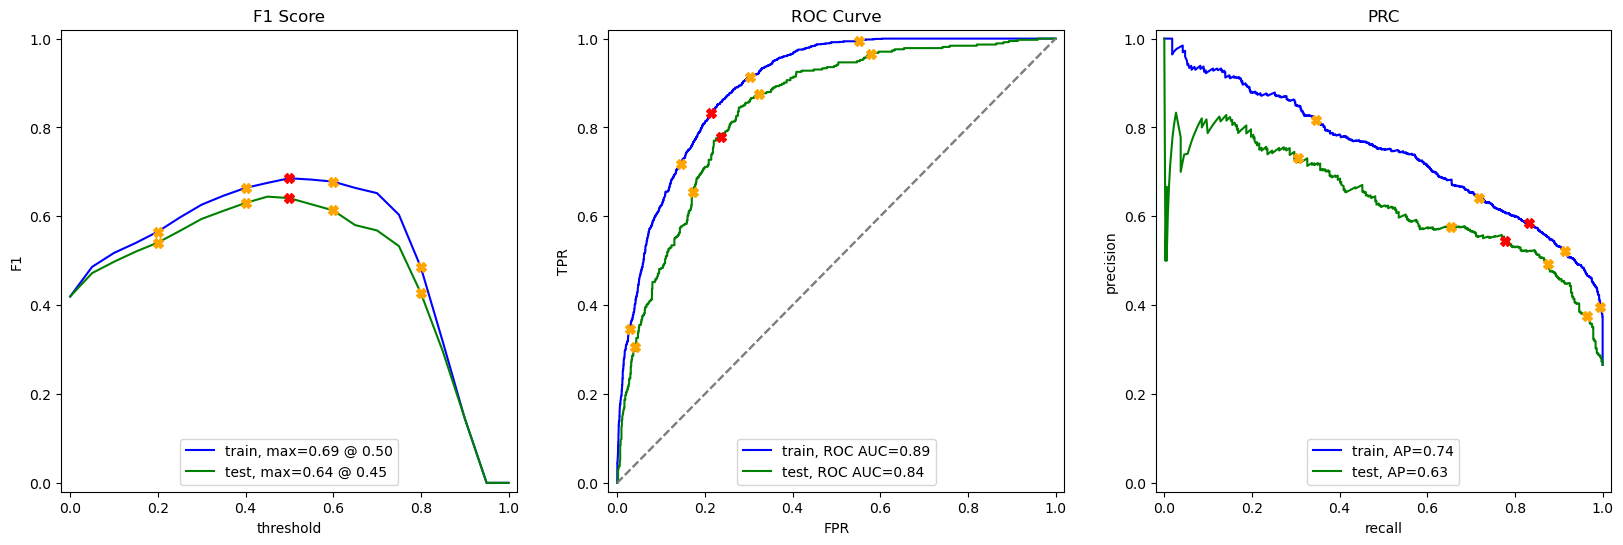

In [15]:
    #!! random forest model with optimal n_estimators and max_depth
rf_model = RandomForestClassifier(n_estimators=21, max_depth=8, class_weight='balanced', random_state=777)
rf_model.fit(features_train, target_train)

evaluate_model(rf_model, features_train, target_train, features_test, target_test)

**- RandomForestClassifier pulls into first place regarding Accuracy and ROC-AUC compared to LogisticRegression (.77 acc, .85 auc) vs (.76 acc, .85 auc)**

## XGBClassifier

          train  test
Accuracy   0.92  0.77
F1         0.85  0.54
APS        0.94  0.62
ROC AUC    0.98  0.82


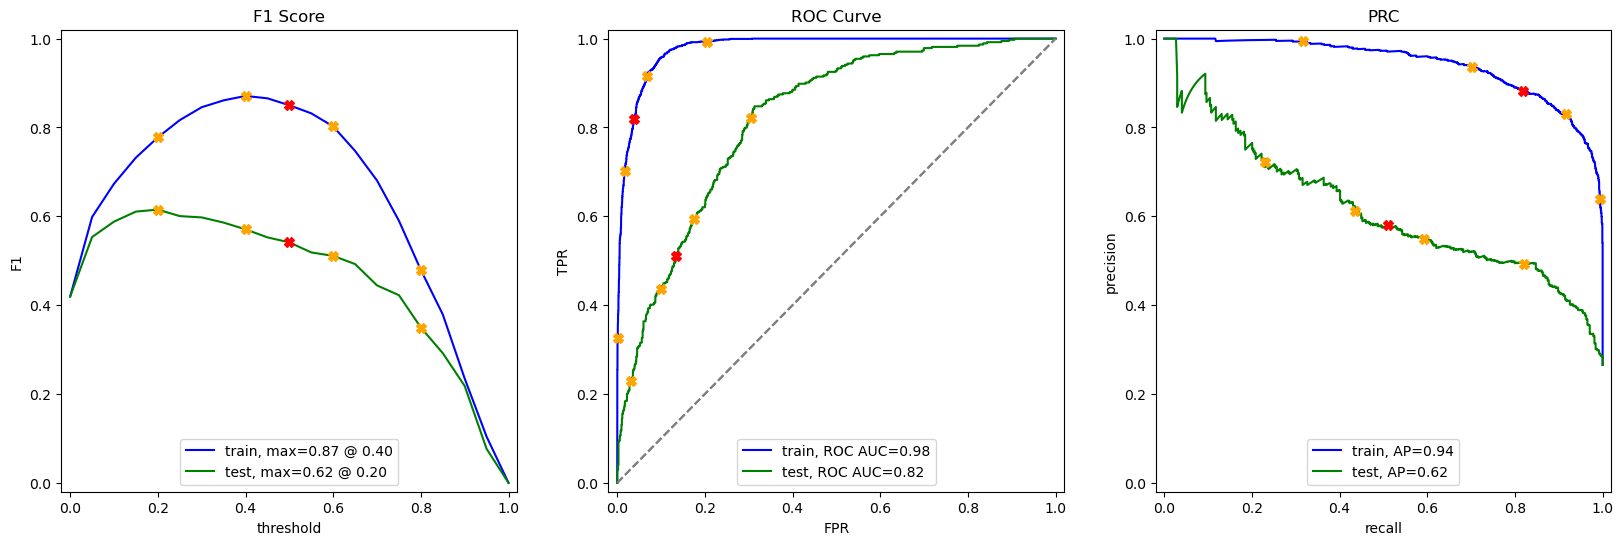

In [16]:
xgb_model = XGBClassifier(eval_metric='auc', random_state=777)
xgb_model.fit(features_train, target_train)

evaluate_model(xgb_model, features_train, target_train, features_test, target_test)

## LGBMClassifier

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
          train  test
Accuracy   0.87  0.78
F1         0.74  0.54
APS        0.86  0.63
ROC AUC    0.95  0.83


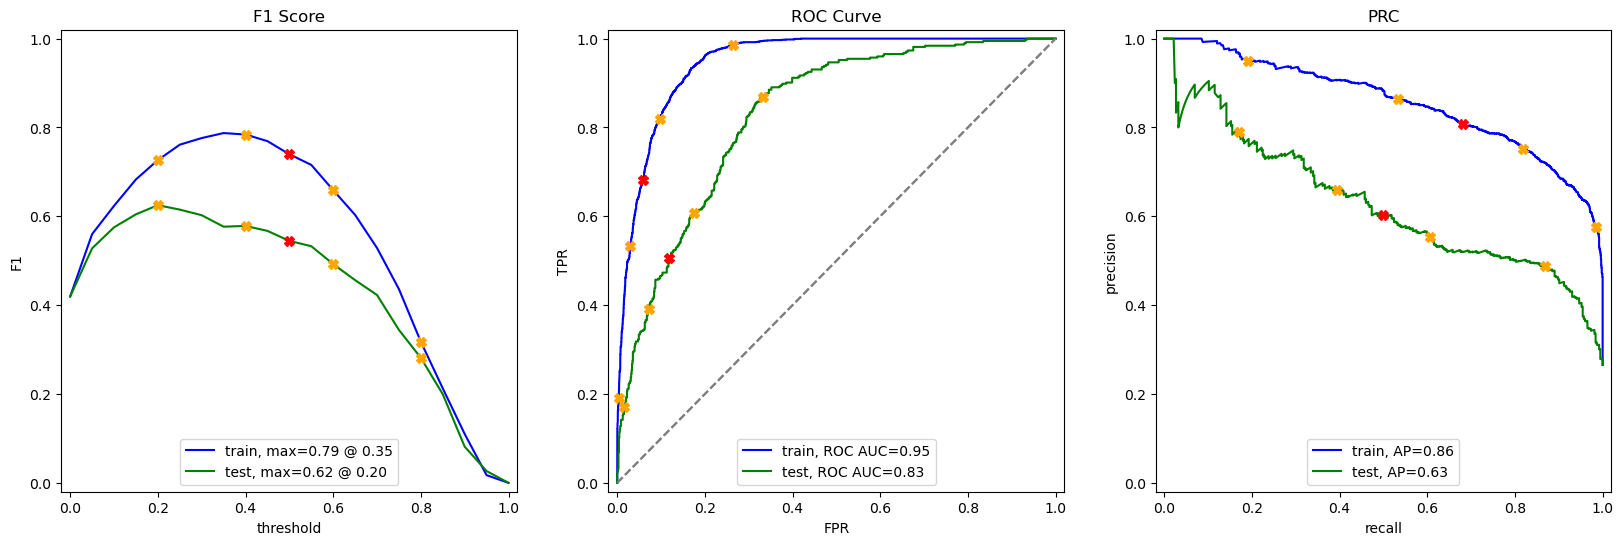

In [17]:
lgbm_model = LGBMClassifier(verbose=0,random_state=777)
lgbm_model.fit(features_train, target_train)

warnings.filterwarnings('ignore')
evaluate_model(lgbm_model, features_train, target_train, features_test, target_test)
warnings.filterwarnings('default')

**write summary**

## CatBoostClassifier

          train  test
Accuracy   0.87  0.79
F1         0.73  0.55
APS        0.84  0.65
ROC AUC    0.94  0.84


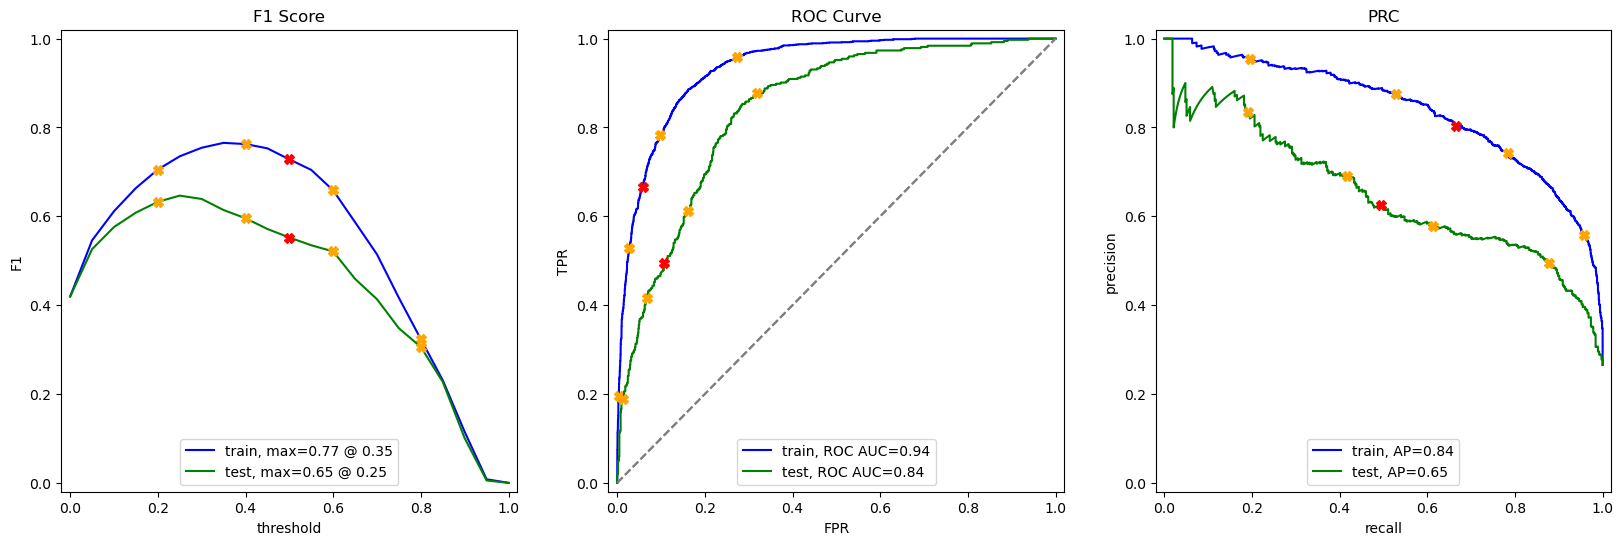

In [18]:
cbc_model = CatBoostClassifier(verbose=0, random_state=777)
cbc_model.fit(features_train, target_train)

evaluate_model(cbc_model, features_train, target_train, features_test, target_test)

**write summary**